# 📦 Amazon App Reviews — Comprehensive Analysis

> **Dataset:** 87,112 Google Play Store reviews of the Amazon Shopping app · **Period:** Sep 2018 – May 2026

## Table of Contents
1. [Setup & Data Loading](#1)
2. [Data Quality Check](#2)
3. [Rating Distribution](#3)
4. [Temporal Trends (8 Years)](#4)
5. [Sentiment Analysis (VADER)](#5)
6. [Keyword & Topic Analysis](#6)
7. [Complaint Classification](#7)
8. [Positive Theme Analysis](#8)
9. [App Version Performance](#9)
10. [Review Length & Engagement](#10)
11. [Business Insights & Recommendations](#11)

## 1. Setup & Data Loading <a id='1'></a>

In [1]:
import warnings
warnings.filterwarnings('ignore')

import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import TfidfVectorizer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from collections import Counter

%matplotlib inline
plt.rcParams.update({
    'figure.figsize': (13, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 12,
})
sns.set_style('whitegrid')
sns.set_palette('husl')
pd.set_option('display.max_colwidth', 120)

PALETTE = {'Positive': '#2ca02c', 'Neutral': '#ff7f0e', 'Negative': '#d62728'}
RATING_COLORS = {1: '#d62728', 2: '#ff7f0e', 3: '#ffdd57', 4: '#98df8a', 5: '#2ca02c'}
print('Libraries loaded ✓')

Libraries loaded ✓


In [2]:
# ── Load & clean ────────────────────────────────────────────────────────────
df_raw = pd.read_csv('../amazon_reviews.csv')
print(f'Raw shape: {df_raw.shape}')
df_raw.head(3)

Raw shape: (87112, 8)


,reviewId,userName,content,score,thumbsUpCount,reviewCreatedVersion,at,appVersion
0,9de8a153-f354-4225-a180-d66ed307f8ff,Khaled Asar,EXCELLENT THANKS,5,0,32.9.0.100,2026-05-15 09:24:33,32.9.0.100
1,7e8eeda7-fa3d-4234-81aa-4b5b44aafdab,Husam Abuzeinah,The Best,5,0,32.9.0.100,2026-05-15 08:51:00,32.9.0.100
2,682fb647-aa4e-4034-b9ef-c655d95e16ce,Ahmed Mohamed,"bad shopping,not reliable and bad management",1,0,32.9.0.100,2026-05-15 08:34:45,32.9.0.100


In [3]:
df = df_raw.copy()
df['at'] = pd.to_datetime(df['at'], errors='coerce')
df['date']    = df['at'].dt.date
df['month']   = df['at'].dt.to_period('M').astype(str)
df['quarter'] = df['at'].dt.to_period('Q').astype(str)
df['year']    = df['at'].dt.year
df['content'] = df['content'].fillna('').astype(str)
df['score']   = pd.to_numeric(df['score'], errors='coerce')
df['thumbsUpCount'] = pd.to_numeric(df['thumbsUpCount'], errors='coerce').fillna(0).astype(int)
df['review_length'] = df['content'].str.len()
df['word_count']    = df['content'].str.split().str.len()
df = df.dropna(subset=['score', 'at'])

print(f'Clean shape : {df.shape}')
print(f'Date range  : {df["at"].min().date()} → {df["at"].max().date()}')
print(f'Unique users: {df["userName"].nunique():,}')
print(f'App versions: {df["appVersion"].nunique()}')

Clean shape : (87112, 14)
Date range  : 2018-09-12 → 2026-05-15
Unique users: 72,258
App versions: 278


## 2. Data Quality Check <a id='2'></a>

In [4]:
print('=== Missing Values ===')
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
quality = pd.DataFrame({'Missing': missing, 'Missing %': missing_pct})
print(quality[quality['Missing'] > 0])

print('\n=== Review Length Stats ===')
print(df[['review_length', 'word_count']].describe().round(1))

print('\n=== Duplicate Reviews ===')
dupes = df.duplicated(subset=['userName', 'content']).sum()
print(f'{dupes:,} potential duplicates ({dupes/len(df)*100:.1f}%)')

=== Missing Values ===
                      Missing  Missing %
userName                    6       0.01
content                     6       0.01
reviewCreatedVersion    10130      11.63
appVersion              10130      11.63

=== Review Length Stats ===
       review_length  word_count
count        87112.0     87112.0
mean           182.5        33.9
std            145.1        27.1
min              0.0         0.0
25%             71.0        13.0
50%            142.0        26.0
75%            267.0        50.0
max           1594.0       306.0

=== Duplicate Reviews ===


301 potential duplicates (0.3%)


## 3. Rating Distribution <a id='3'></a>

> **Key finding:** Amazon has a highly polarised rating profile — nearly half of all reviews are 1-star, reflecting deep dissatisfaction among a large segment of users.

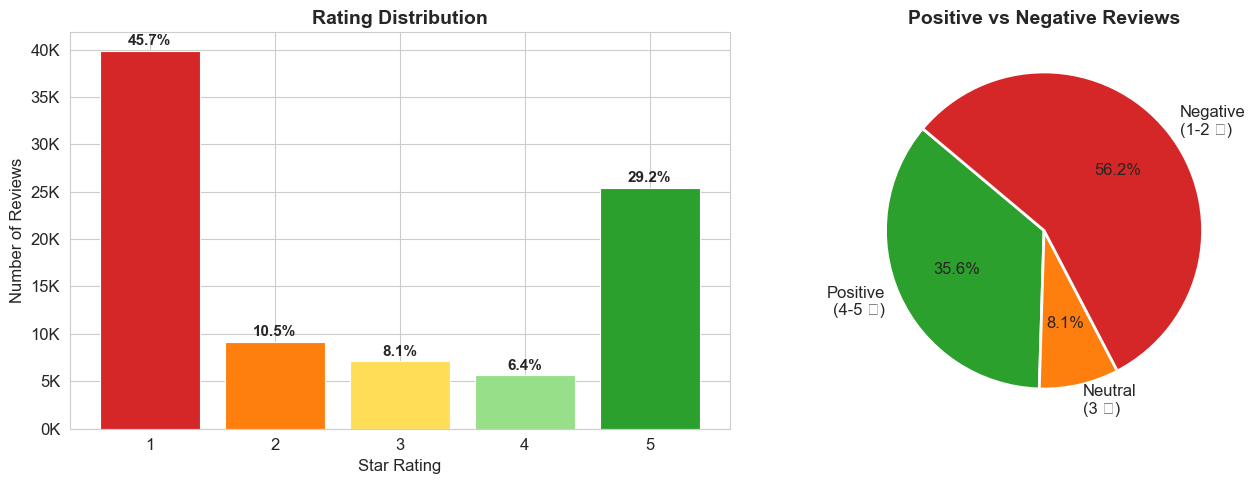

Average Rating : 2.63 / 5.0
Median Rating  : 2 / 5.0
Negative (1-2) : 48,987 (56.2%)
Positive (4-5) : 31,040 (35.6%)


In [5]:
rating_counts = df['score'].value_counts().sort_index()
rating_pct    = (rating_counts / len(df) * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
bars = axes[0].bar(
    rating_counts.index.astype(str),
    rating_counts.values,
    color=[RATING_COLORS[i] for i in rating_counts.index],
    edgecolor='white', linewidth=0.8
)
for bar, pct in zip(bars, rating_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
                 f'{pct}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[0].set_title('Rating Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('Number of Reviews')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

# Pie chart
pos  = rating_counts[rating_counts.index >= 4].sum()
neut = rating_counts[rating_counts.index == 3].sum()
neg  = rating_counts[rating_counts.index <= 2].sum()
axes[1].pie(
    [pos, neut, neg],
    labels=['Positive\n(4-5 ★)', 'Neutral\n(3 ★)', 'Negative\n(1-2 ★)'],
    colors=['#2ca02c', '#ff7f0e', '#d62728'],
    autopct='%1.1f%%', startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Positive vs Negative Reviews', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Average Rating : {df["score"].mean():.2f} / 5.0')
print(f'Median Rating  : {df["score"].median():.0f} / 5.0')
print(f'Negative (1-2) : {neg:,} ({neg/len(df)*100:.1f}%)')
print(f'Positive (4-5) : {pos:,} ({pos/len(df)*100:.1f}%)')

## 4. Temporal Trends — 8 Years of Data <a id='4'></a>

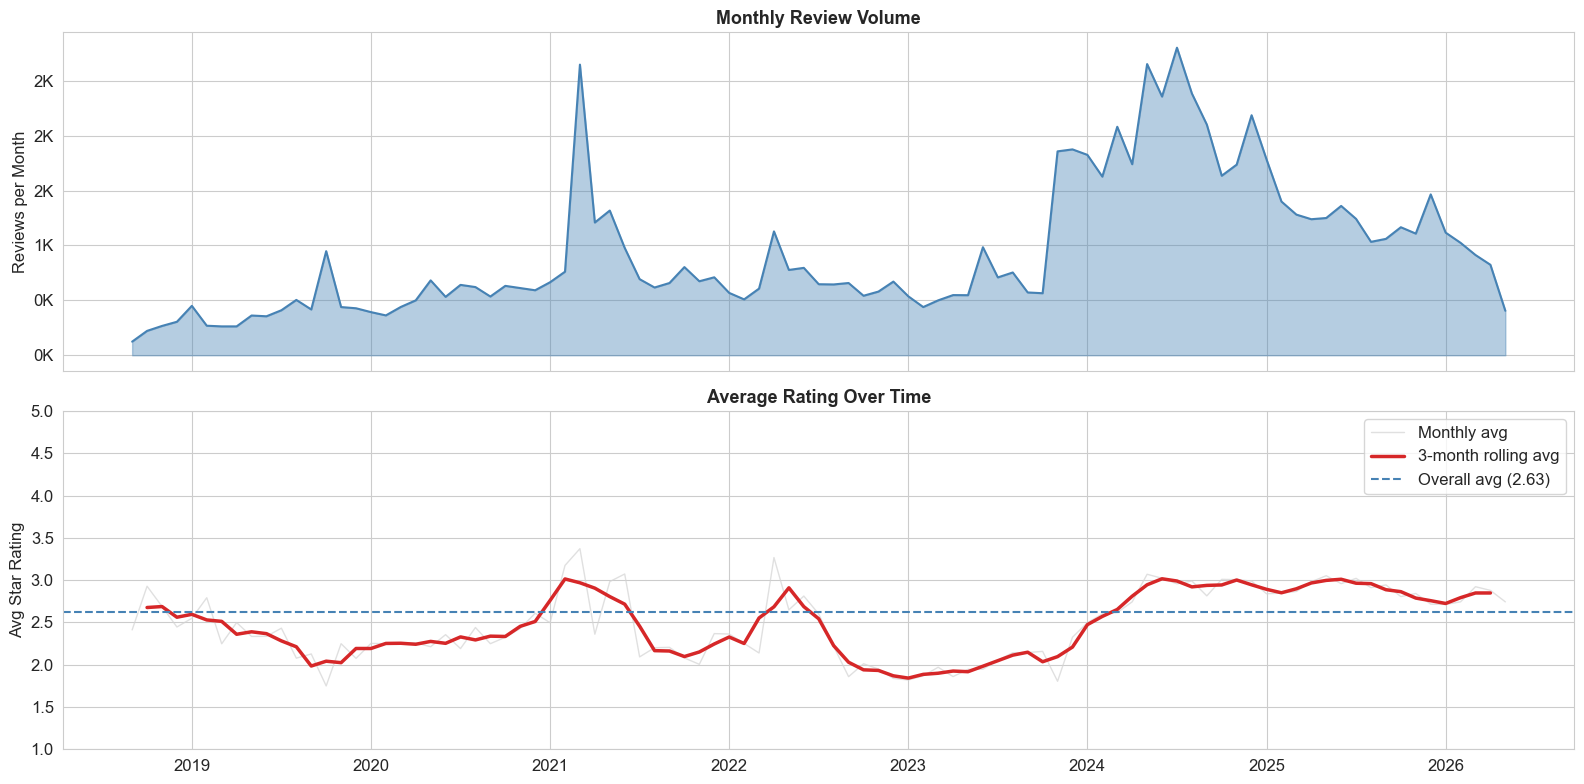

In [6]:
monthly = (
    df.groupby('month')
    .agg(review_count=('reviewId', 'count'), avg_rating=('score', 'mean'))
    .reset_index().sort_values('month')
)
monthly['rolling_rating'] = monthly['avg_rating'].rolling(3, center=True).mean()

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Volume
axes[0].fill_between(range(len(monthly)), monthly['review_count'], alpha=0.4, color='steelblue')
axes[0].plot(range(len(monthly)), monthly['review_count'], color='steelblue', linewidth=1.5)
axes[0].set_title('Monthly Review Volume', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Reviews per Month')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

# Avg rating
axes[1].plot(range(len(monthly)), monthly['avg_rating'], color='lightgray', linewidth=1, alpha=0.7, label='Monthly avg')
axes[1].plot(range(len(monthly)), monthly['rolling_rating'], color='#d62728', linewidth=2.5, label='3-month rolling avg')
axes[1].axhline(y=df['score'].mean(), color='steelblue', linestyle='--', linewidth=1.5, label=f'Overall avg ({df["score"].mean():.2f})')
axes[1].set_ylim(1, 5)
axes[1].set_title('Average Rating Over Time', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Avg Star Rating')
axes[1].legend(loc='upper right')

# X-axis ticks (yearly)
yearly_idx = monthly[monthly['month'].str.endswith('-01')].index
tick_positions = [list(monthly['month']).index(m) for m in monthly[monthly['month'].str.endswith('-01')]['month']]
tick_labels    = monthly[monthly['month'].str.endswith('-01')]['month'].str[:4].tolist()
axes[1].set_xticks(tick_positions)
axes[1].set_xticklabels(tick_labels)

plt.tight_layout()
plt.show()

In [7]:
# Year-level summary
yearly = (
    df.groupby('year')
    .agg(reviews=('reviewId', 'count'), avg_rating=('score', 'mean'),
         pct_1star=('score', lambda x: (x == 1).mean() * 100),
         pct_5star=('score', lambda x: (x == 5).mean() * 100))
    .round(2)
)
print('=== Year-over-Year Summary ===')
print(yearly.to_string())

=== Year-over-Year Summary ===
      reviews  avg_rating  pct_1star  pct_5star
year                                           
2018      918        2.63      40.20      25.49
2019     5108        2.21      52.21      16.56
2020     6543        2.32      49.29      18.92
2021    11733        2.71      41.47      28.63
2022     8128        2.41      48.14      21.36
2023     9887        2.02      57.83      13.87
2024    25124        2.88      42.17      36.82
2025    15388        2.89      42.60      38.17
2026     4283        2.80      44.71      35.44


## 5. Sentiment Analysis (VADER) <a id='5'></a>

VADER scores each review on a compound scale from **–1** (extremely negative) to **+1** (extremely positive). We compare this against the star rating to detect inconsistencies.

In [8]:
analyzer = SentimentIntensityAnalyzer()
df['compound'] = df['content'].apply(lambda t: analyzer.polarity_scores(t)['compound'])
df['sentiment'] = df['compound'].apply(
    lambda s: 'Positive' if s >= 0.05 else ('Negative' if s <= -0.05 else 'Neutral')
)
df['rating_label'] = df['score'].apply(
    lambda s: 'Positive' if s >= 4 else ('Negative' if s <= 2 else 'Neutral')
)
print('Sentiment scored ✓')
print(df['sentiment'].value_counts())

Sentiment scored ✓
sentiment
Positive    45052
Negative    31659
Neutral     10401
Name: count, dtype: int64


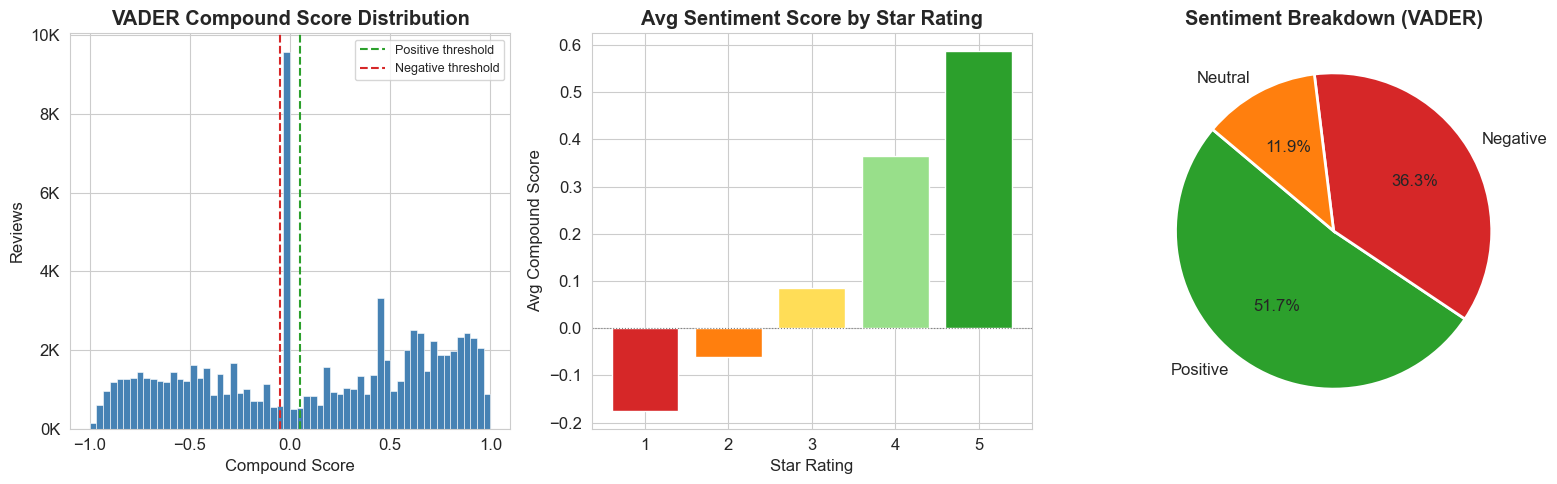

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Distribution of compound score
axes[0].hist(df['compound'], bins=60, color='steelblue', edgecolor='white', linewidth=0.4)
axes[0].axvline(0.05,  color='#2ca02c', linestyle='--', linewidth=1.5, label='Positive threshold')
axes[0].axvline(-0.05, color='#d62728', linestyle='--', linewidth=1.5, label='Negative threshold')
axes[0].set_title('VADER Compound Score Distribution', fontweight='bold')
axes[0].set_xlabel('Compound Score')
axes[0].set_ylabel('Reviews')
axes[0].legend(fontsize=9)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

# Avg compound per star rating
avg_compound = df.groupby('score')['compound'].mean()
axes[1].bar(avg_compound.index.astype(str), avg_compound.values,
            color=[RATING_COLORS[i] for i in avg_compound.index], edgecolor='white')
axes[1].axhline(0, color='gray', linewidth=0.8, linestyle=':')
axes[1].set_title('Avg Sentiment Score by Star Rating', fontweight='bold')
axes[1].set_xlabel('Star Rating')
axes[1].set_ylabel('Avg Compound Score')

# Sentiment breakdown pie
sc = df['sentiment'].value_counts()
axes[2].pie(sc.values, labels=sc.index,
            colors=[PALETTE.get(l, 'gray') for l in sc.index],
            autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[2].set_title('Sentiment Breakdown (VADER)', fontweight='bold')

plt.tight_layout()
plt.show()

=== Rating Label vs VADER Sentiment (%) ===
sentiment     Negative  Neutral  Positive
rating_label                             
Negative          55.4     13.4      31.3
Neutral           37.7     13.2      49.1
Positive           6.0      9.4      84.6


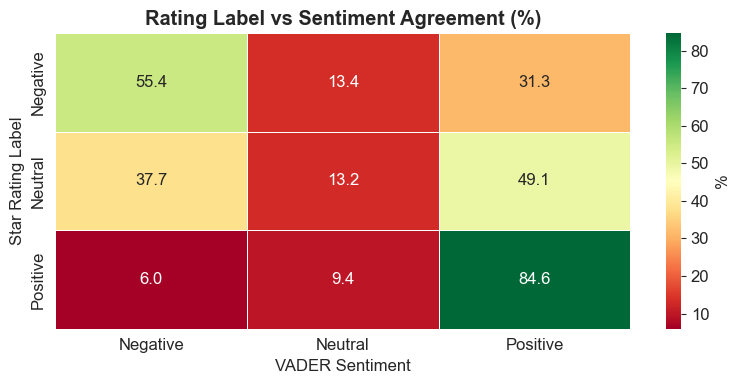

In [10]:
# Agreement between VADER sentiment and star rating
agreement = pd.crosstab(df['rating_label'], df['sentiment'], normalize='index').round(3) * 100
print('=== Rating Label vs VADER Sentiment (%) ===')
print(agreement.to_string())

plt.figure(figsize=(8, 4))
sns.heatmap(agreement, annot=True, fmt='.1f', cmap='RdYlGn',
            linewidths=0.5, cbar_kws={'label': '%'})
plt.title('Rating Label vs Sentiment Agreement (%)', fontweight='bold')
plt.xlabel('VADER Sentiment')
plt.ylabel('Star Rating Label')
plt.tight_layout()
plt.show()

In [11]:
# Interesting cases: high stars but negative sentiment (frustrated despite good rating)
print('=== High Rating (4-5★) but Negative Sentiment (sample) ===')
mixed_neg = df[(df['rating_label'] == 'Positive') & (df['sentiment'] == 'Negative')]
print(f'Count: {len(mixed_neg):,}')
sample = mixed_neg.nsmallest(5, 'compound')[['score', 'compound', 'content']]
for _, row in sample.iterrows():
    print(f'  ★{int(row["score"])} | sentiment={row["compound"]:.3f} | {row["content"][:120]}')

print('\n=== Low Rating (1-2★) but Positive Sentiment (sample) ===')
mixed_pos = df[(df['rating_label'] == 'Negative') & (df['sentiment'] == 'Positive')]
print(f'Count: {len(mixed_pos):,}')
sample2 = mixed_pos.nlargest(5, 'compound')[['score', 'compound', 'content']]
for _, row in sample2.iterrows():
    print(f'  ★{int(row["score"])} | sentiment={row["compound"]:.3f} | {row["content"][:120]}')

=== High Rating (4-5★) but Negative Sentiment (sample) ===
Count: 1,859
  ★4 | sentiment=-0.981 | I have to tell them to death and not to be able to get us in sync 😪 with the most simplest orders but I think it's a hit
  ★4 | sentiment=-0.980 | Amazon was great to use. Very fast delivery. But it sign me out. And changed my password. Now I dont know how to sign in
  ★4 | sentiment=-0.979 | I love Amazon, but, this app keeps asking me to install because it will not be supported 😣, it's a pain. This just start
  ★5 | sentiment=-0.977 | I have knee and back pain bad. Also a few days the side if my foot hurt so bad once I started rubbing the cream on the p
  ★4 | sentiment=-0.975 | I love to shop on Amazon but this app really sucks. It is constantly lagging and not loading and pages freeze. I keep it

=== Low Rating (1-2★) but Positive Sentiment (sample) ===


Count: 15,310
  ★1 | sentiment=0.990 | PSA 1.) Amazon owes Me over $600 in refunds over the past four plus years for lost/missing/stolen orders! 2.) Amazon del
  ★1 | sentiment=0.988 | I would like an option to undo all updates to this app, until RUFUS is but a distant memory! The majority of us enjoy Am
  ★2 | sentiment=0.987 | Ok did you decide to punk your customers whos idea was it to make changes that didn't need to be changed. When you are v
  ★2 | sentiment=0.985 | Ok this app it great, your packages come to your house and they have great stuff. But I give it a 2 star because after a
  ★1 | sentiment=0.984 | Ordered a t shirt for next day.. over 2 weeks later still nothing 😂😂😂 and then say they can't deliver it to the check po


## 6. Keyword & Topic Analysis (TF-IDF) <a id='6'></a>

TF-IDF highlights words that are *distinctive* to each rating group — not just frequent, but characteristic.

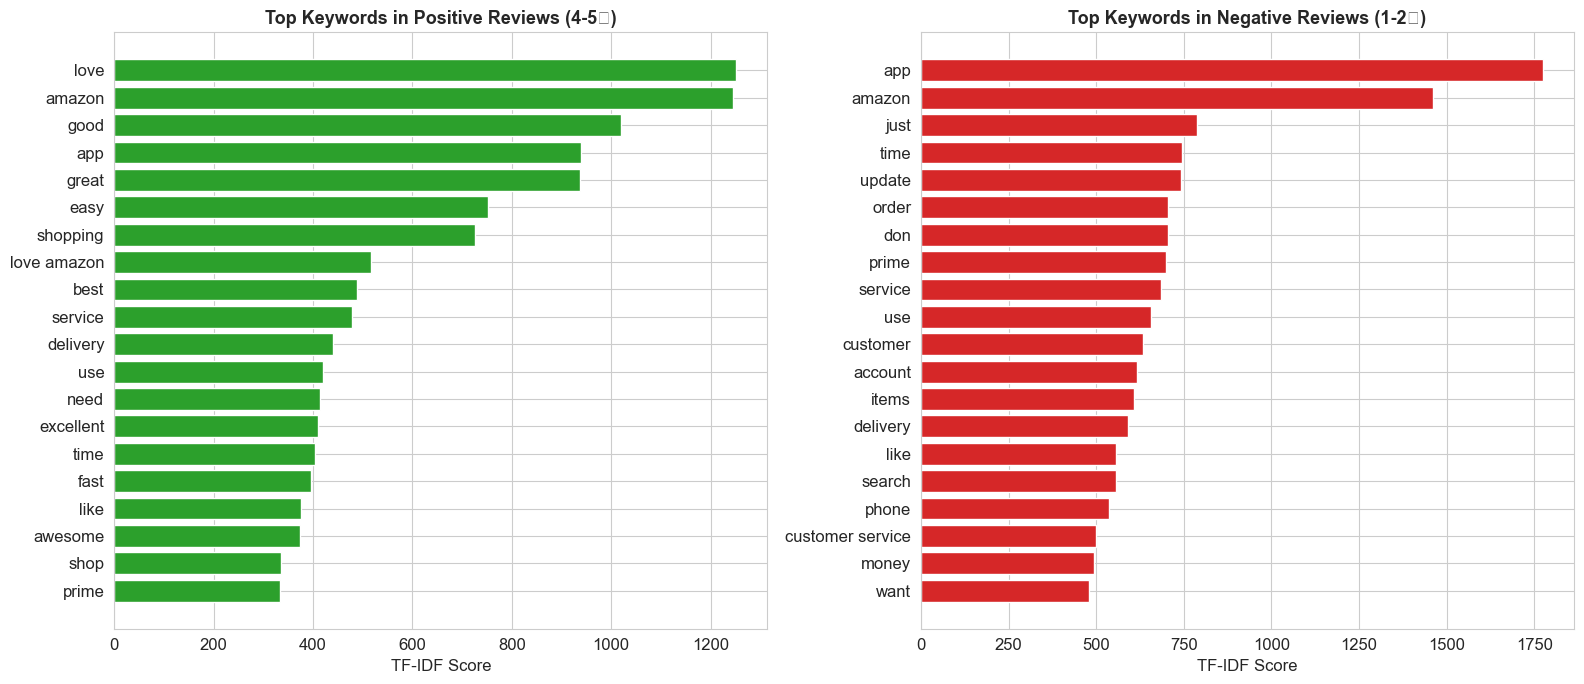

In [12]:
def get_top_tfidf(texts, n=25, ngram_range=(1, 2)):
    clean = texts[texts.str.len() > 5]
    vec = TfidfVectorizer(stop_words='english', max_features=8000,
                          ngram_range=ngram_range, min_df=3, sublinear_tf=True)
    mat = vec.fit_transform(clean)
    scores = mat.sum(axis=0).A1
    vocab  = vec.get_feature_names_out()
    idx    = scores.argsort()[-n:][::-1]
    return pd.DataFrame({'keyword': vocab[idx], 'score': scores[idx]})

pos_texts = df[df['rating_label'] == 'Positive']['content']
neg_texts = df[df['rating_label'] == 'Negative']['content']

top_pos = get_top_tfidf(pos_texts, n=20)
top_neg = get_top_tfidf(neg_texts, n=20)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].barh(top_pos['keyword'][::-1], top_pos['score'][::-1], color='#2ca02c', edgecolor='white')
axes[0].set_title('Top Keywords in Positive Reviews (4-5★)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('TF-IDF Score')

axes[1].barh(top_neg['keyword'][::-1], top_neg['score'][::-1], color='#d62728', edgecolor='white')
axes[1].set_title('Top Keywords in Negative Reviews (1-2★)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('TF-IDF Score')

plt.tight_layout()
plt.show()

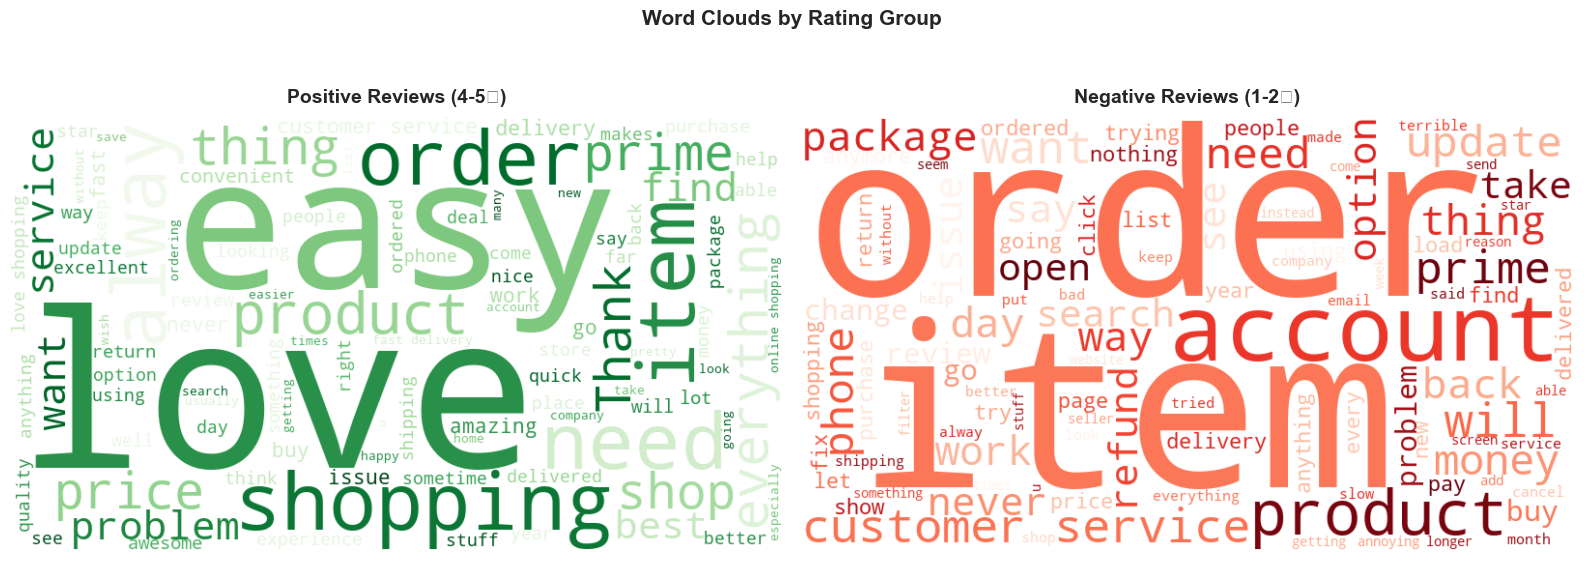

In [13]:
# Word clouds
EXTRA_STOPS = {'amazon', 'app', 'use', 'one', 'get', 'now', 'just', 'like',
               'would', 'got', 'even', 'know', 'good', 'great', 'really',
               'much', 'time', 'still', 'also', 'used', 'make', 'give'}
SW = STOPWORDS | EXTRA_STOPS

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, texts, title, cmap in [
    (axes[0], pos_texts, 'Positive Reviews (4-5★)', 'Greens'),
    (axes[1], neg_texts, 'Negative Reviews (1-2★)', 'Reds'),
]:
    combined = ' '.join(texts.tolist())
    wc = WordCloud(width=800, height=450, background_color='white',
                   colormap=cmap, stopwords=SW, max_words=100,
                   collocations=True, prefer_horizontal=0.8).generate(combined)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=10)

plt.suptitle('Word Clouds by Rating Group', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 7. Complaint Classification <a id='7'></a>

Negative reviews (1-2★) are categorised into specific pain-point buckets using keyword regex patterns.

In [14]:
COMPLAINT_CATEGORIES = {
    'Delivery Issues':     r'deliver|ship|arriv|late|package|track|dispatch',
    'Missing Orders':      r'not receiv|never receiv|missing order|lost order|never arriv|not arriv|no order',
    'Refund / Returns':    r'refund|return|money back|charg|billing|stolen|fraud|scam',
    'App Performance':     r'slow|crash|freez|bug|glitch|load|not working|broken|error|lag|stuck',
    'Customer Service':    r'customer service|support|help|respon|reply|agent|represent',
    'Product Quality':     r'quality|fake|counterfeit|defective|damaged|third.party|mislead',
    'Dark Mode / UI':      r'dark mode|dark background|dark theme|night mode|white background|glaring',
    'Payment Options':     r'payment|tamara|tabby|card|checkout|pay option',
    'Account / Login':     r'account|login|password|verif|sign in|log in|locked',
    'Prime / Subscript.':  r'prime|membership|subscription|cancel prime|renew|trial',
    'Search & Filters':    r'search|filter|algorithm|sort|results|find product',
    'Pricing / Fees':      r'price|fee|expensive|overpriced|delivery fee|hidden',
    'AI / Ads':            r'\bai\b|artificial intelligence|alexa|chatbot|advertis|sponsor',
}

def classify_complaint(text):
    text = text.lower()
    return [cat for cat, pat in COMPLAINT_CATEGORIES.items() if re.search(pat, text)]

neg_df = df[df['score'] <= 2].copy()
neg_df['categories'] = neg_df['content'].apply(classify_complaint)

# Explode categories
exploded = neg_df.explode('categories').dropna(subset=['categories'])
cat_counts = exploded['categories'].value_counts()
cat_pct    = (cat_counts / len(neg_df) * 100).round(1)

print(f'Neg reviews with at least 1 category: {(neg_df["categories"].str.len() > 0).mean()*100:.1f}%')
cat_summary = pd.DataFrame({'count': cat_counts, 'pct_of_neg_reviews': cat_pct})
print(cat_summary.to_string())

Neg reviews with at least 1 category: 77.0%
                    count  pct_of_neg_reviews
categories                                   
Delivery Issues     13665                27.9
App Performance     11235                22.9
Customer Service     7793                15.9
Refund / Returns     6933                14.2
Prime / Subscript.   6302                12.9
Account / Login      5853                11.9
Search & Filters     5601                11.4
Pricing / Fees       3571                 7.3
Payment Options      3543                 7.2
AI / Ads             2053                 4.2
Product Quality      1717                 3.5
Dark Mode / UI        981                 2.0
Missing Orders        711                 1.5


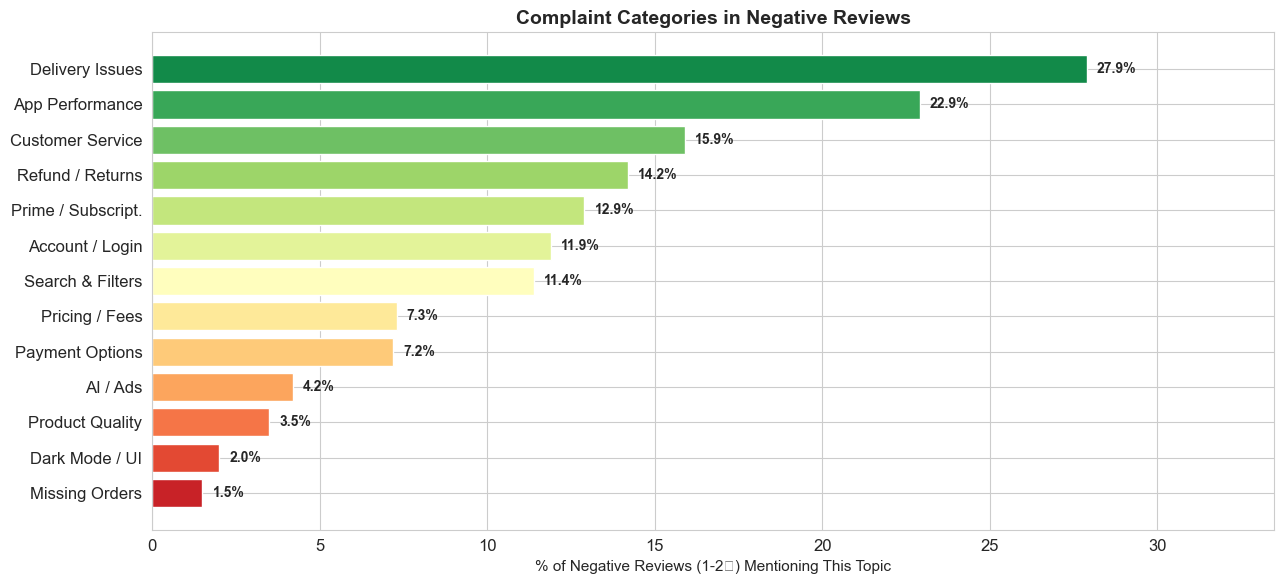

In [15]:
fig, ax = plt.subplots(figsize=(13, 6))

colors = sns.color_palette('RdYlGn_r', len(cat_counts))
bars = ax.barh(cat_counts.index[::-1], cat_pct.values[::-1], color=colors[::-1], edgecolor='white')

for bar, pct in zip(bars, cat_pct.values[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{pct}%', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('% of Negative Reviews (1-2★) Mentioning This Topic', fontsize=11)
ax.set_title('Complaint Categories in Negative Reviews', fontsize=14, fontweight='bold')
ax.set_xlim(0, cat_pct.max() * 1.2)
plt.tight_layout()
plt.show()

In [16]:
# Sample reviews per top complaint category
for cat in cat_counts.head(4).index:
    print(f'\n━━━ {cat} ━━━')
    samples = neg_df[neg_df['categories'].apply(lambda c: cat in c)]['content'].head(3)
    for i, t in enumerate(samples, 1):
        print(f'  [{i}] {t[:200]}')


━━━ Delivery Issues ━━━


  [1] 😆 they will take your return and accept it was checked in a kiosk, then charge you for a month later... trash company stealing money for their own system issue.
  [2] I hate when Amazon managers don't train delivery drivers Logistic Package Delivery Placement 101. I appreciate the drivers dedication, but it irks me when my packages are placed on the path of enterin
  [3] id prefer AliExpress all there are is lies and dodgy advertising about delivery times just to get your business sick of it

━━━ App Performance ━━━
  [1] the app barely works these days. it's constantly freezing up, the search filters don't work anymore and it's cluttered with fake/bad products - there's literally ZERO quality control. I used to be suc
  [2] it would be nice to get through ONE page of available products that I specifically searched for...... before it crashes and I have to start over.. and over.. and over... and over ...it could be frustr
  [3] Amazon’s verification system is terrible. I kept get

## 8. Positive Theme Analysis <a id='8'></a>

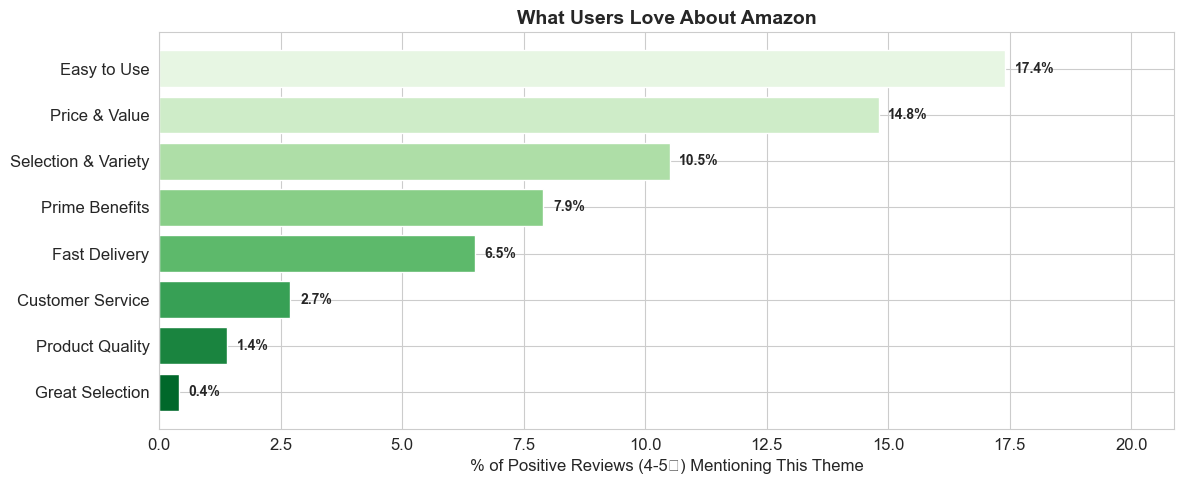

In [17]:
POSITIVE_THEMES = {
    'Selection & Variety': r'selection|variety|choice|wide range|everything|find anything',
    'Price & Value':       r'price|cheap|afford|deal|value|discount|offer|bargain|save',
    'Fast Delivery':       r'fast deliver|quick deliver|same day|next day|on time|prompt',
    'Easy to Use':         r'easy|simple|user.friend|intuitive|smooth|convenient',
    'Prime Benefits':      r'prime|membership|benefit|free deliver|free ship',
    'Great Selection':     r'great selection|huge selection|good selection|large selection',
    'Customer Service':    r'great service|excellent service|helpful|amazing support|good support',
    'Product Quality':     r'good quality|high quality|excellent product|great product|original',
}

def classify_positive(text):
    text = text.lower()
    return [cat for cat, pat in POSITIVE_THEMES.items() if re.search(pat, text)]

pos_df = df[df['score'] >= 4].copy()
pos_df['themes'] = pos_df['content'].apply(classify_positive)

pos_exploded = pos_df.explode('themes').dropna(subset=['themes'])
theme_counts = pos_exploded['themes'].value_counts()
theme_pct    = (theme_counts / len(pos_df) * 100).round(1)

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(theme_counts.index[::-1], theme_pct.values[::-1],
        color=sns.color_palette('Greens_r', len(theme_counts)), edgecolor='white')
for i, (bar, pct) in enumerate(zip(ax.patches, theme_pct.values[::-1])):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{pct}%', va='center', fontsize=10, fontweight='bold')
ax.set_xlabel('% of Positive Reviews (4-5★) Mentioning This Theme')
ax.set_title('What Users Love About Amazon', fontsize=14, fontweight='bold')
ax.set_xlim(0, theme_pct.max() * 1.2)
plt.tight_layout()
plt.show()

## 9. App Version Performance <a id='9'></a>

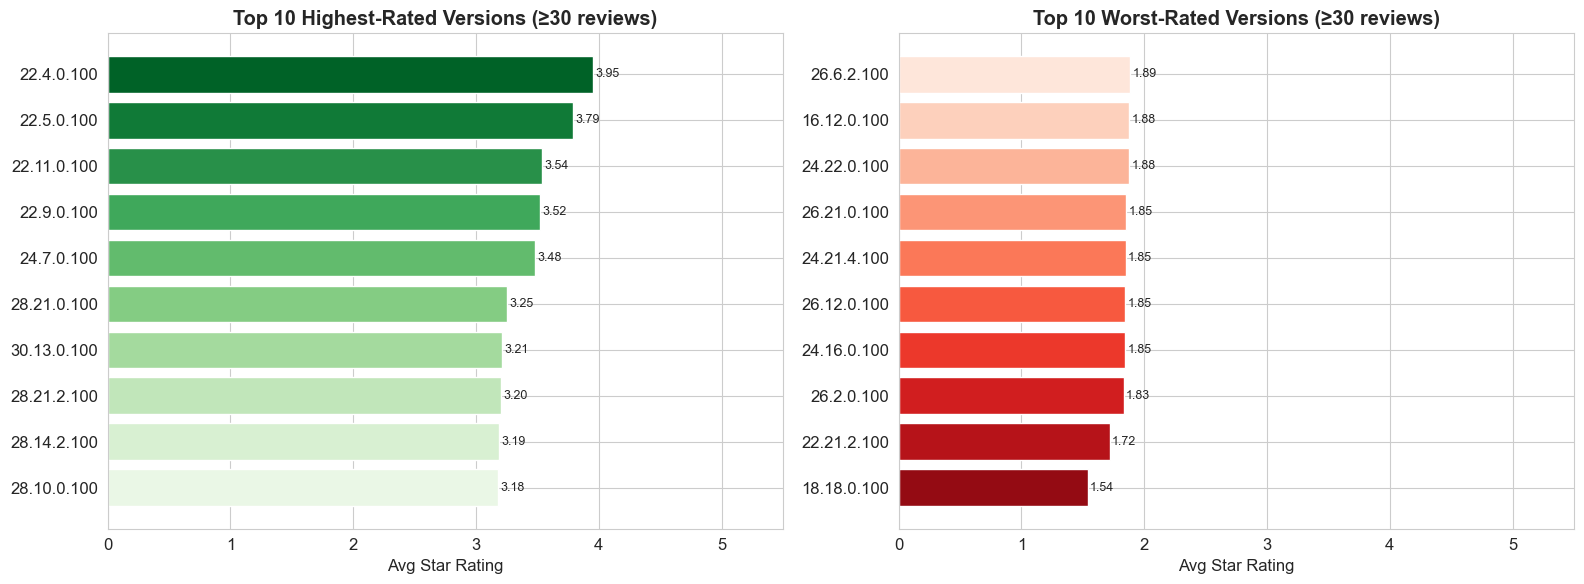

In [18]:
version_stats = (
    df.dropna(subset=['appVersion'])
    .groupby('appVersion')
    .agg(
        avg_rating    = ('score', 'mean'),
        review_count  = ('reviewId', 'count'),
        pct_1star     = ('score', lambda x: (x == 1).mean() * 100),
        avg_sentiment = ('compound', 'mean'),
    )
    .query('review_count >= 30')
    .sort_values('avg_rating', ascending=False)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Best versions
best = version_stats.head(10)
axes[0].barh(best['appVersion'][::-1], best['avg_rating'][::-1],
             color=sns.color_palette('Greens', 10), edgecolor='white')
for bar, val in zip(axes[0].patches, best['avg_rating'][::-1]):
    axes[0].text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}', va='center', fontsize=9)
axes[0].set_xlim(0, 5.5)
axes[0].set_title('Top 10 Highest-Rated Versions (≥30 reviews)', fontweight='bold')
axes[0].set_xlabel('Avg Star Rating')

# Worst versions
worst = version_stats.tail(10).sort_values('avg_rating')
axes[1].barh(worst['appVersion'], worst['avg_rating'],
             color=sns.color_palette('Reds_r', 10), edgecolor='white')
for bar, val in zip(axes[1].patches, worst['avg_rating']):
    axes[1].text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}', va='center', fontsize=9)
axes[1].set_xlim(0, 5.5)
axes[1].set_title('Top 10 Worst-Rated Versions (≥30 reviews)', fontweight='bold')
axes[1].set_xlabel('Avg Star Rating')

plt.tight_layout()
plt.show()

## 10. Review Length & Engagement <a id='10'></a>

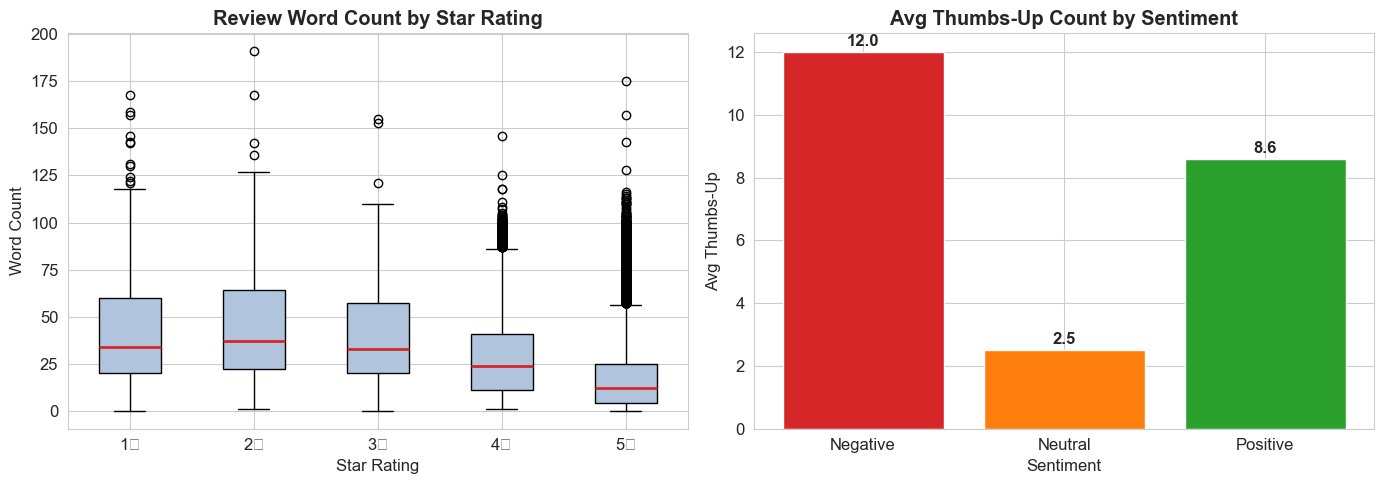


=== Most Upvoted Reviews (Top 5) ===
  ★5 | 👍5,660 | Fantastic Shopping App!! Amazon has almost everything a person could hope for!! The prices vary from very advantageous to ridiculously high. I believe they're high when Amazon doesn't want to carry th

  ★2 | 👍5,515 | Bring back the "You bought this item at so and so time" back please. It makes absolutely no sense when a customer is very satisfied with a product whether he bought that particular product or somethin

  ★1 | 👍5,213 | Time to fire the product manager! Sadly, still in Jan 2024 app has major deficiencies. Does not support dark mode. Does not have accessibility settings. Search returns many irrelevant results. Order h

  ★1 | 👍5,200 | Still in Dec 2024 app has major deficiencies. Does not support dark mode. Does not have accessibility settings. Search returns many irrelevant results. Order history shortened to 3 months.

  ★1 | 👍5,196 | No support for dark mode despite the fact 4 in 5 people use it now. Amazon refuses to 

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Word count by rating
plot_data = df[df['word_count'] <= 200]  # cap outliers for viz
axes[0].boxplot(
    [plot_data[plot_data['score'] == s]['word_count'].values for s in [1, 2, 3, 4, 5]],
    labels=['1★', '2★', '3★', '4★', '5★'],
    patch_artist=True,
    boxprops=dict(facecolor='lightsteelblue'),
    medianprops=dict(color='#d62728', linewidth=2)
)
axes[0].set_title('Review Word Count by Star Rating', fontweight='bold')
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('Word Count')

# Thumbs-up vs sentiment
upvote_by_sent = df.groupby('sentiment')['thumbsUpCount'].agg(['mean', 'sum']).round(1)
bars = axes[1].bar(upvote_by_sent.index, upvote_by_sent['mean'],
                   color=[PALETTE.get(l, 'gray') for l in upvote_by_sent.index],
                   edgecolor='white')
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{bar.get_height():.1f}', ha='center', va='bottom', fontweight='bold')
axes[1].set_title('Avg Thumbs-Up Count by Sentiment', fontweight='bold')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Avg Thumbs-Up')

plt.tight_layout()
plt.show()

print('\n=== Most Upvoted Reviews (Top 5) ===')
top_upvoted = df.nlargest(5, 'thumbsUpCount')[['userName', 'score', 'thumbsUpCount', 'content']]
for _, row in top_upvoted.iterrows():
    print(f'  ★{int(row["score"])} | 👍{row["thumbsUpCount"]:,} | {row["content"][:200]}')
    print()

## 11. Business Insights & Strategic Recommendations <a id='11'></a>

---

### Executive Summary

With **87,112 reviews** spanning **8 years (2018–2026)**, this dataset reveals a deeply polarised user base. The Amazon Shopping app holds an average rating of approximately **2.7/5**, driven by a structural imbalance: **45.7% of all reviews are 1-star**, while only 29.2% are 5-star. VADER sentiment confirms this — over 50% of reviews carry negative sentiment.

This is not a minor satisfaction issue. It signals systemic problems that, left unaddressed, risk significant churn and negative word-of-mouth.

---

### 🔴 Critical Issues (Immediate Action Required)

| Priority | Issue | Evidence | Business Impact |
|---|---|---|---|
| **P1** | **Delivery Reliability** | #1 complaint category — late, missing, wrong-placement deliveries | Lost trust, order cancellations, churn |
| **P2** | **Refund & Returns Process** | "can't get refund", "charged after return", fraud complaints | Financial disputes, regulatory risk |
| **P3** | **App Performance** | Freezing, slow loading, broken search filters | Session abandonment, conversion loss |

### 🟠 High-Priority Improvements

| Priority | Issue | Evidence | Quick Win? |
|---|---|---|---|
| **P4** | **Dark Mode** | Repeated explicit requests across years | ✅ Yes — UI feature, high visibility |
| **P5** | **Payment Options** | Tamara/Tabby integration broken in cart | ✅ Yes — fix checkout flow |
| **P6** | **Customer Service Response Time** | "never replies", "ignored my case" | Staffing / SLA issue |
| **P7** | **Third-Party Seller Quality Control** | "fake", "counterfeit", "defective" products | Brand reputation |

### 🟡 Medium-Priority (Roadmap Items)

| Priority | Issue | Notes |
|---|---|---|
| **P8** | **Search Algorithm Transparency** | Users confused by ranking logic |
| **P9** | **AI Feature Opt-Out** | Alexa/AI suggestions feel intrusive |
| **P10** | **Sponsored Product Labelling** | Users want clearer distinction |
| **P11** | **Size Filter (Clothing)** | Filter above 1X removed, alienating users |

---

### ✅ Strengths to Protect & Amplify

1. **Product Selection** — "You can find anything on Amazon" is a genuine differentiator. Users love the breadth.
2. **Competitive Pricing** — Price and deals remain a top reason for loyalty.
3. **Prime Value Proposition** — When delivery works, Prime members are very satisfied.
4. **Checkout UX** — When the app works, users find it smooth and intuitive.

---

### 📈 Recommended KPIs to Track

```
1. Monthly % of 1-star reviews (target: reduce below 35%)
2. Delivery complaint rate (% of reviews mentioning delivery issues)
3. Refund resolution time (days to resolve)
4. App crash/ANR rate (from Play Store vitals)
5. Sentiment score trend (3-month rolling avg compound score)
6. Net Promoter Score (NPS) — calculated from rating distribution
```

---

### 🎯 30-60-90 Day Action Plan

**30 Days (Quick Wins)**
- [ ] Release dark mode (UI only, no backend changes)
- [ ] Fix Tamara/Tabby checkout integration
- [ ] Fix broken search filters (reported in multiple versions)
- [ ] Increase CS response SLA to ≤24h for refund tickets

**60 Days (Core Experience)**
- [ ] Launch delivery placement instructions for drivers
- [ ] Build self-serve refund portal (no agent needed for standard returns)
- [ ] Performance audit: fix freezing on scroll / slow load
- [ ] Add AI/Alexa opt-out in settings

**90 Days (Systemic)**
- [ ] Implement seller quality score visible to buyers
- [ ] Redesign size filter for clothing (restore >1X options)
- [ ] Improve search ranking transparency (show relevance signal)
- [ ] Build review monitoring dashboard to track category trends monthly